<a href="https://colab.research.google.com/github/noobcoded17/bakajuan-mobilenetv3-model/blob/main/Mangrove_Classifier_with_Sample_Predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ====================================
# 0. Install Required Packages
# ====================================
!pip install --upgrade pip
!pip install tensorflow==2.16.1 matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 589.9/589.9 MB 36.5 MB/s  0:00:09
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 51.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 71.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 80.1 MB/s  0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard

In [ ]:
# ====================================
# 1. Imports
# ====================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from google.colab import drive
drive.mount('/content/drive')

print("TensorFlow version:", tf.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.16.1


In [ ]:
# ====================================
# 2. Paths & Parameters
# ====================================
base_dir = "/content/drive/MyDrive/DATASETS"
train_dir = base_dir + "/TRAINING"
val_dir   = base_dir + "/VALIDATION"
test_dir  = base_dir + "/TEST"

img_size = (224, 224)
batch_size = 32

# ====================================
# 3. Load datasets
# ====================================
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='int'  # ensures labels are integer for sparse_categorical_crossentropy
)

val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='int'
)

test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='int'
)

# Get class names
class_names = train_ds_raw.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Optimize pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds_raw.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds_raw.prefetch(buffer_size=AUTOTUNE)


Found 1964 files belonging to 5 classes.
Found 427 files belonging to 5 classes.
Found 427 files belonging to 5 classes.
Classes: ['BAKHAW_BABAE', 'BUTA_BUTA', 'MIYAPI', 'PAGATPAT', 'POTOTAN']


In [ ]:
# ====================================
# 4. Data Augmentation Layer
# ====================================
def random_brightness(img):
    # TF 2.16.1 requires dtype uint8 or float32 in [0,1] for random_brightness
    img = tf.image.convert_image_dtype(img, dtype=tf.float32)
    img = tf.image.random_brightness(img, max_delta=0.2)
    return img

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
    layers.Lambda(random_brightness)
])

In [ ]:
# ====================================
# 5. Build Model (MobileNetV3-Large)
# ====================================
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=img_size + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze backbone first

inputs = keras.Input(shape=img_size + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v3.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         4,805 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,001,157 (11.45 MB)

 Trainable params: 4,805 (18.77 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [ ]:
# ====================================
# 6. Train Model
# ====================================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=[early_stop]
)

Epoch 1/35
62/62 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.3832 - loss: 1.5941 - val_accuracy: 0.6440 - val_loss: 0.9213
Epoch 2/35
62/62 ━━━━━━━━━━━━━━━━━━━━ 345s 3s/step - accuracy: 0.7411 - loss: 0.7198 - val_accuracy: 0.7190 - val_loss: 0.7021
Epoch 3/35
62/62 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.8285 - loss: 0.5128 - val_accuracy: 0.7845 - val_loss: 0.5752
Epoch 4/35
62/62 ━━━━━━━━━━━━━━━━━━━━ 347s 3s/step - accuracy: 0.8580 - loss: 0.4304 - val_accuracy: 0.8478 - val_loss: 0.4465
Epoch 5/35
62/62 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.9006 - loss: 0.3671 - val_accuracy: 0.8126 - val_loss: 0.4740
Epoch 6/35
62/62 ━━━━━━━━━━━━━━━━━━━━ 404s 3s/step - accuracy: 0.8882 - loss: 0.3570 - val_accuracy: 0.8314 - val_loss: 0.4284
Epoch 7/35
62/62 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.8978 - loss: 0.3247 - val_accuracy: 0.8314 - val_loss: 0.4268
Epoch 8/35
62/62 ━━━━━━━━━━━━━━━━━━━━ 350s 3s/step - accuracy: 0.9073 - loss: 0.2873 - val_accuracy: 0.8337 - v

14/14 ━━━━━━━━━━━━━━━━━━━━ 115s 8s/step - accuracy: 0.9155 - loss: 0.2313
Test Accuracy: 0.9133489727973938
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Classification Report:

              precision    recall  f1-score   support

BAKHAW_BABAE       0.83      0.93      0.88        86
   BUTA_BUTA       0.95      0.91      0.93        89
      MIYAPI       0.89      0.93      0.91        85
    PAGATPAT       0.96      0.97      0.97        79
     POTOTAN       0.95      0.83      0.88        88

    accuracy                         

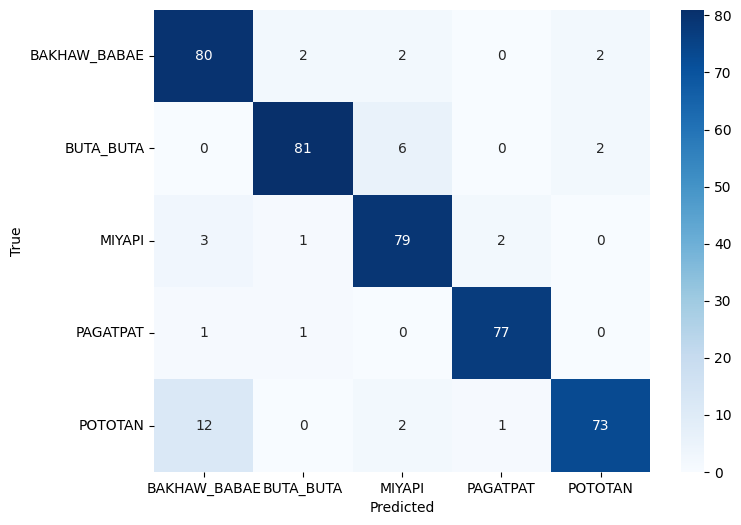

In [ ]:
# ====================================
# 7. Evaluate Model
# ====================================
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

# ====================================
# 8. Confusion Matrix & Report
# ====================================
y_true = []
y_pred = []

for images, labels in test_ds_raw:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
import tensorflow as tf
import os

# ====================================
# 1️⃣ Define paths
# ====================================
saved_model_path = '/content/drive/MyDrive/MLMODEL/temp_keras_saved_model'
tflite_model_path = '/content/drive/MyDrive/MLMODEL/converted_model.tflite'

# Ensure the folder exists
os.makedirs(os.path.dirname(saved_model_path), exist_ok=True)

# ====================================
# 2️⃣ Save the trained Keras model
# ====================================
print(f"Saving model to: {saved_model_path}")
try:
    model.export(saved_model_path)  # Keras 3 / TF 2.16+
except AttributeError:
    model.save(saved_model_path, save_format='tf')  # fallback

print("Model saved successfully.")

# ====================================
# 3️⃣ Convert the SavedModel to TFLite
# ====================================
print("Starting TFLite conversion...")
tflite_converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)

# Enable select TensorFlow ops
tflite_converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS # Enable select TensorFlow ops
]

# Optional: optimization for smaller & faster model
tflite_converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Optional: support float16 quantization (reduces size)
# tflite_converter.target_spec.supported_types = [tf.float16]

# Perform the conversion
tflite_model = tflite_converter.convert()
print("TFLite conversion complete.")

# ====================================
# 4️⃣ Save the TFLite model
# ====================================
with open(tflite_model_path, "wb") as f:
    f.write(tflite_model)
print(f"TFLite model saved to: {tflite_model_path}")

Saving model to: /content/drive/MyDrive/MLMODEL/temp_keras_saved_model
Saved artifact at '/content/drive/MyDrive/MLMODEL/temp_keras_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_203')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  137216526486608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137216526487184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137216526487760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137216526486800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137216526489488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137216526489680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137216526487568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137216526490256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137216526490448: TensorSpec(shape=(), dtyp

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

def evaluate_model(model, dataset, class_names, dataset_name="Dataset"):
    y_true, y_pred = [], []

    for images, labels in dataset:
        preds = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    # Classification report
    print(f"\n📊 Classification Report for {dataset_name}:\n")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n🧮 Confusion Matrix for {dataset_name}:\n{cm}")

    # Overall accuracy
    overall_acc = accuracy_score(y_true, y_pred)
    print(f"\n✅ Overall Accuracy for {dataset_name}: {overall_acc:.4f}")
    return overall_acc

# --- Evaluate Training Accuracy ---
train_acc = evaluate_model(model, train_ds_raw, class_names, dataset_name="Training Set")

# --- Evaluate Test Accuracy ---
test_acc = evaluate_model(model, test_ds_raw, class_names, dataset_name="Test Set")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

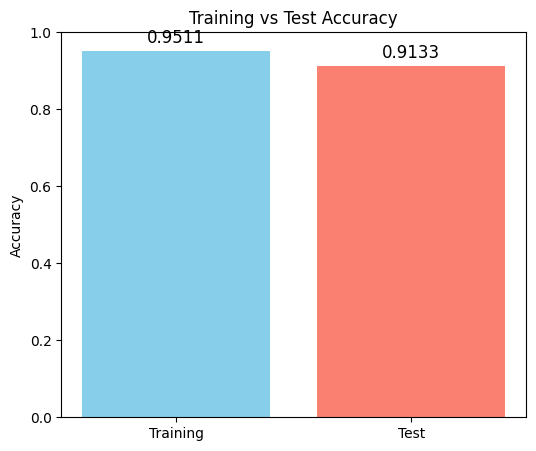

In [ ]:
import matplotlib.pyplot as plt

# Final accuracies (from previous evaluation)
accuracies = [train_acc, test_acc]
datasets = ['Training', 'Test']

plt.figure(figsize=(6,5))
bars = plt.bar(datasets, accuracies, color=['skyblue', 'salmon'])
plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy')

# Add accuracy labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.4f}", ha='center', fontsize=12)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

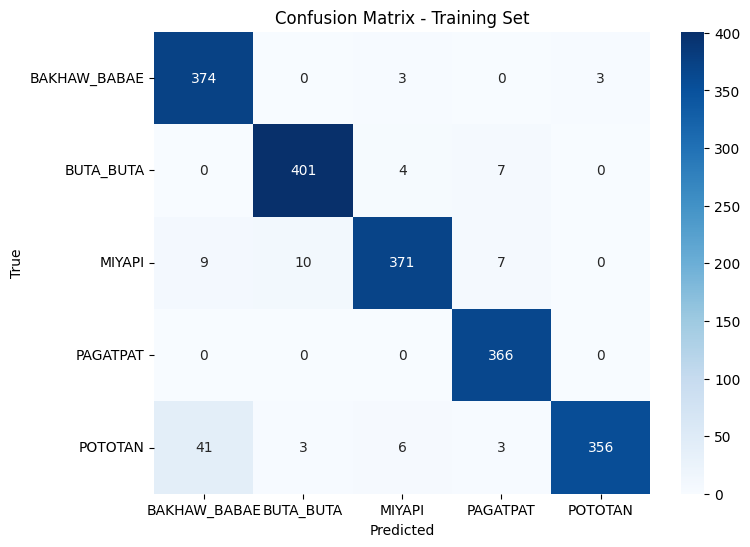

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# --- Collect predictions and true labels for training set ---
y_true_train, y_pred_train = [], []

for images, labels in train_ds_raw:
    preds = model.predict(images)
    y_true_train.extend(labels.numpy())
    y_pred_train.extend(np.argmax(preds, axis=1))

# --- Confusion Matrix ---
cm_train = confusion_matrix(y_true_train, y_pred_train)

plt.figure(figsize=(8,6))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Training Set")
plt.show()


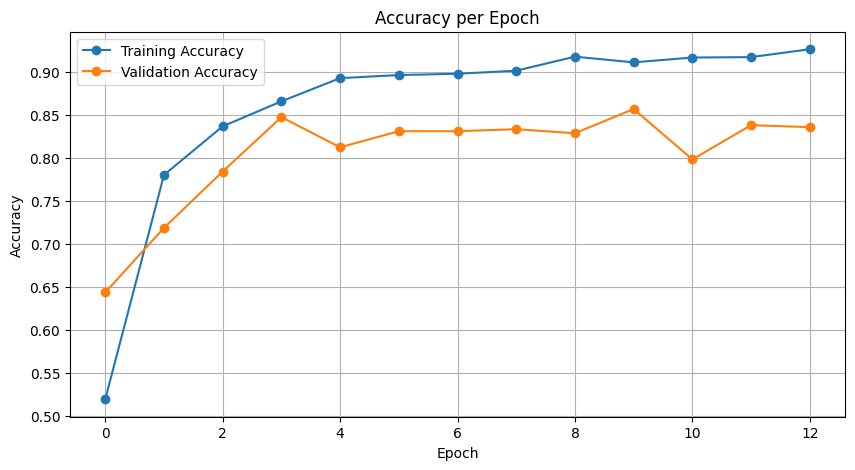

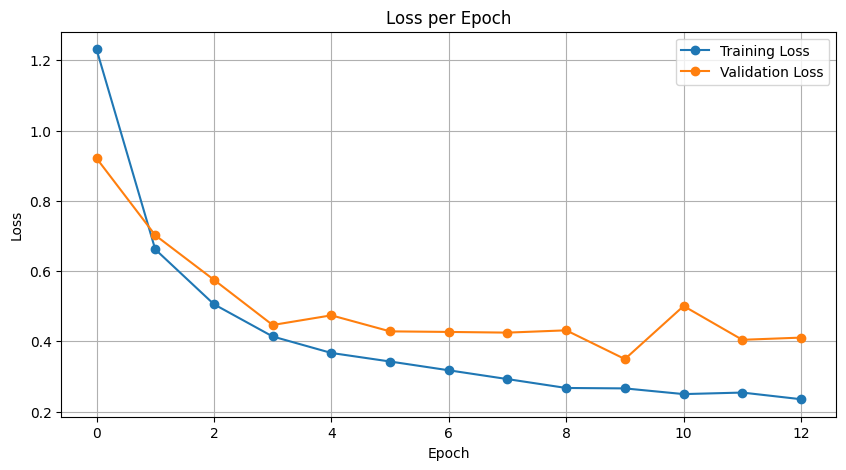

In [ ]:
import matplotlib.pyplot as plt

# Assume you have trained your model like this:
# history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# --- Accuracy per epoch ---
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# --- Loss per epoch ---
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


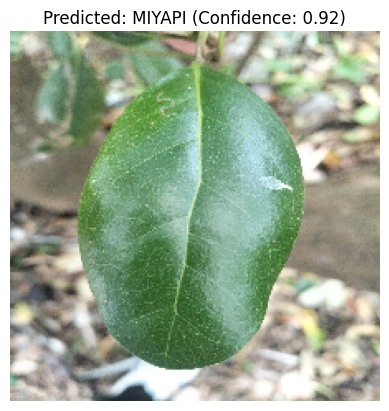

In [ ]:
# ====================================
# 1. Load and preprocess image
# ====================================
img_path = "/content/drive/MyDrive/DATASETS/TEST/MIYAPI/IMG20250729125822.jpg" # change path
img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # make batch of 1
img_array = tf.keras.applications.mobilenet_v3.preprocess_input(img_array)

# ====================================
# 2. Get predictions and confidence
# ====================================
predictions = model.predict(img_array)
highest_confidence = np.max(predictions[0])
predicted_class_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_class_index]
threshold = .75

# ====================================
# 3. Apply Confidence Threshold and Display
# ====================================
plt.imshow(img)
plt.axis("off")

if highest_confidence < threshold:
    plt.title(f"Prediction: Image is not recognized as Bakawan Leaf (Confidence: {highest_confidence:.2f})")
else:
    plt.title(f"Predicted: {predicted_class} (Confidence: {highest_confidence:.2f})")

plt.show()

In [ ]:
import glob

# get first jpg image in folder
files = glob.glob("/content/drive/MyDrive/DATASETS/TEST/PAGATPAT/IMG_20250808_140803.jpg")
print("Found files:", files)

if files:
    img_path = files[0]  # take the first image
    print("Using:", img_path)
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
else:
    print("⚠️ No .jpg files found in folder!")


Found files: ['/content/drive/MyDrive/DATASETS/TEST/PAGATPAT/IMG_20250808_140803.jpg']
Using: /content/drive/MyDrive/DATASETS/TEST/PAGATPAT/IMG_20250808_140803.jpg


Input shape: [  1 224 224   3]
Using image: /content/drive/MyDrive/DATASETS/TEST/MIYAPI/IMG20250729125737.jpg

✅ Prediction: miyapi
Confidence: 0.6411751


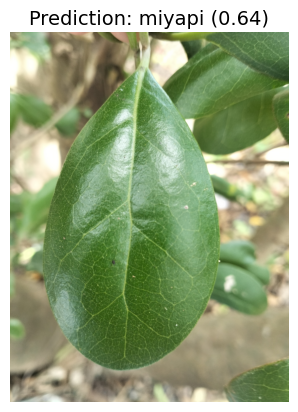

In [ ]:
import tensorflow as tf
import numpy as np
import glob
from PIL import Image
import matplotlib.pyplot as plt

# ==============================
# 1. Load the TFLite model
# ==============================
tflite_model_path = "/content/drive/MyDrive/MLMODEL/converted_model.tflite"
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input shape:", input_details[0]['shape'])

# ==============================
# 2. Pick an image to test
# ==============================
files = glob.glob("/content/drive/MyDrive/DATASETS/TEST/MIYAPI/*.jpg")
if not files:
    raise FileNotFoundError("⚠️ No .jpg files found in folder.")
img_path = files[0]
print("Using image:", img_path)

# ==============================
# 3. Preprocess image
# ==============================
img = Image.open(img_path).resize((224, 224))          # resize to model input
img_array = np.array(img, dtype=np.float32) / 255.0    # normalize like training
img_array = np.expand_dims(img_array, axis=0)          # add batch dimension

# ==============================
# 4. Run inference
# ==============================
interpreter.set_tensor(input_details[0]['index'], img_array)
interpreter.invoke()
preds = interpreter.get_tensor(output_details[0]['index'])[0]

# ==============================
# 5. Get predicted class
# ==============================
class_names = ["butabuta", "miyapi", "class3", "class4", "class5"]  # update with your labels
pred_index = np.argmax(preds)
pred_label = class_names[pred_index]
confidence = preds[pred_index]

print("\n✅ Prediction:", pred_label)
print("Confidence:", confidence)

# ==============================
# 6. Display image with prediction
# ==============================
plt.imshow(Image.open(img_path))
plt.axis("off")
plt.title(f"Prediction: {pred_label} ({confidence:.2f})", fontsize=14)
plt.show()


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32
)

datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

class_names = list(train_gen.class_indices.keys())
print("Class names:", class_names)



Found 1964 files belonging to 5 classes.
Found 1964 images belonging to 5 classes.
Class names: ['BAKHAW_BABAE', 'BUTA_BUTA', 'MIYAPI', 'PAGATPAT', 'POTOTAN']


In [ ]:
class_names = train_ds.class_names
print("Class names:", class_names)


Class names: ['BAKHAW_BABAE', 'BUTA_BUTA', 'MIYAPI', 'PAGATPAT', 'POTOTAN']


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

# ====================================
# 1. Load Pretrained Backbone
# ====================================
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # freeze first

# ====================================
# 2. Build Classifier Head
# ====================================
inputs = keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.mobilenet_v3.preprocess_input(inputs)  # ✅ keep [-1,1] scaling
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(5, activation="softmax")(x)  # 5 classes
model = keras.Model(inputs, outputs)

# Compile initial model (frozen backbone)
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",  # ✅ correct for int labels
    metrics=["accuracy"]
)

# ====================================
# 3. Train Frozen Backbone (Warm-up)
# ====================================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# ====================================
# 4. Unfreeze Last Layers for Fine-tuning
# ====================================
base_model.trainable = True

# Keep only last ~50 layers trainable
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ====================================
# 5. Fine-tune
# ====================================
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)


Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 325s 5s/step - accuracy: 0.4547 - loss: 1.3696 - val_accuracy: 0.8361 - val_loss: 0.5842
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 315s 5s/step - accuracy: 0.8519 - loss: 0.4805 - val_accuracy: 0.8970 - val_loss: 0.4045
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 319s 5s/step - accuracy: 0.8936 - loss: 0.3421 - val_accuracy: 0.9087 - val_loss: 0.3485
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 284s 5s/step - accuracy: 0.9282 - loss: 0.2605 - val_accuracy: 0.9297 - val_loss: 0.2972
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 346s 5s/step - accuracy: 0.9352 - loss: 0.2256 - val_accuracy: 0.9297 - val_loss: 0.2808
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 282s 5s/step - accuracy: 0.9463 - loss: 0.1818 - val_accuracy: 0.9368 - val_loss: 0.2482
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 352s 5s/step - accuracy: 0.9409 - loss: 0.1875 - val_accuracy: 0.9415 - val_loss: 0.2369
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 292s 5s/step - accuracy: 0.9621 - loss: 0.1512 - val_accuracy: 0.9344 - v

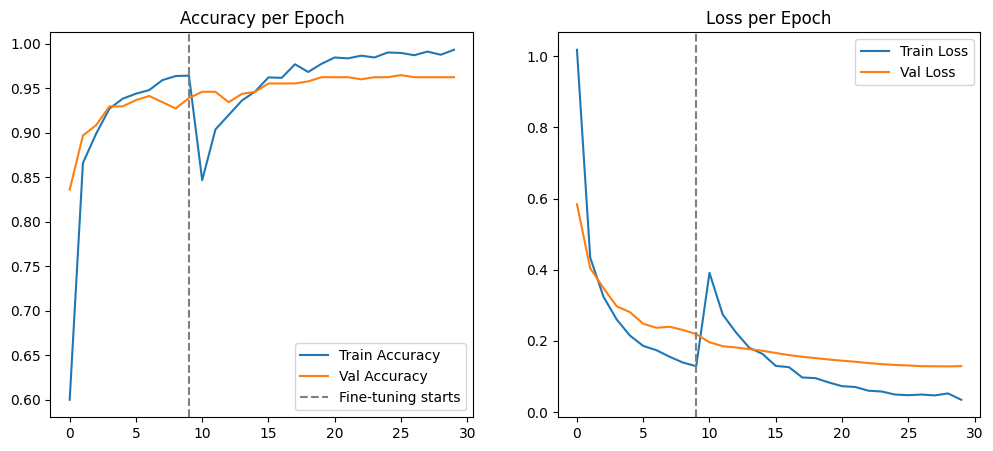

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history1, history2):
    acc = history1.history['accuracy'] + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss = history1.history['loss'] + history2.history['loss']
    val_loss = history1.history['val_loss'] + history2.history['val_loss']

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(acc, label="Train Accuracy")
    plt.plot(val_acc, label="Val Accuracy")
    plt.axvline(x=len(history1.history['accuracy'])-1, color='gray', linestyle='--', label="Fine-tuning starts")
    plt.legend()
    plt.title("Accuracy per Epoch")

    # Loss
    plt.subplot(1,2,2)
    plt.plot(loss, label="Train Loss")
    plt.plot(val_loss, label="Val Loss")
    plt.axvline(x=len(history1.history['loss'])-1, color='gray', linestyle='--')
    plt.legend()
    plt.title("Loss per Epoch")

    plt.show()

plot_history(history, fine_tune_history)


In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=2)
print(f"\n✅ Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

14/14 - 51s - 4s/step - accuracy: 0.9602 - loss: 0.1046

✅ Test Accuracy: 0.9602, Test Loss: 0.1046


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


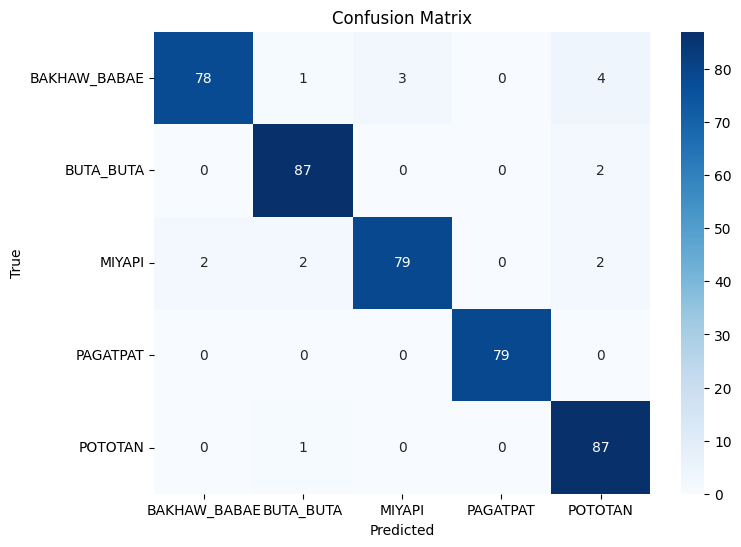


📊 Classification Report:

              precision    recall  f1-score   support

BAKHAW_BABAE     0.9750    0.9070    0.9398        86
   BUTA_BUTA     0.9560    0.9775    0.9667        89
      MIYAPI     0.9634    0.9294    0.9461        85
    PAGATPAT     1.0000    1.0000    1.0000        79
     POTOTAN     0.9158    0.9886    0.9508        88

    accuracy                         0.9602       427
   macro avg     0.9620    0.9605    0.9607       427
weighted avg     0.9612    0.9602    0.9601       427



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_ds.class_names,
            yticklabels=train_ds.class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=train_ds.class_names, digits=4))


In [ ]:
# Export as SavedModel (folder format required for TFLite)
model.export("/content/drive/MyDrive/MLMODEL/final_mangrove_model")


Saved artifact at '/content/drive/MyDrive/MLMODEL/final_mangrove_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_628')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  137215849481232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137215849481424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137215849482384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137215849482000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137215849482192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137215849480848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137215849481616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137215849481808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137215849480656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137215849483344: TensorSpec(shape=(), dtype=t

In [ ]:
# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_saved_model(
    "/content/drive/MyDrive/MLMODEL/final_mangrove_model"
)
tflite_model = converter.convert()

# Save as .tflite file
with open("/content/drive/MyDrive/MLMODEL/mangrove_model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ TFLite model saved at: /content/drive/MyDrive/MLMODEL/mangrove_model.tflite")


✅ TFLite model saved at: /content/drive/MyDrive/MLMODEL/mangrove_model.tflite


Saving IMG20250912125129.jpg to IMG20250912125129.jpg


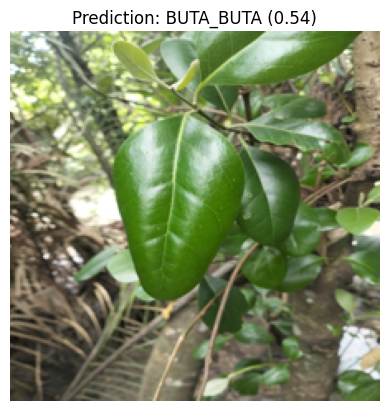

✅ Predicted: BUTA_BUTA (Confidence: 0.54)


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# ================================
# Upload local image
# ================================
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # get uploaded filename

# ================================
# Prediction function with display
# ================================
def predict_tflite(image_path):
    # Load and preprocess image
    img = Image.open(image_path).convert("RGB").resize((224, 224))
    input_data = np.expand_dims(np.array(img, dtype=np.float32), axis=0)

    # Run TFLite inference
    interpreter = tf.lite.Interpreter(model_path="/content/drive/MyDrive/MLMODEL/mangrove_model.tflite")
    interpreter.allocate_tensors()

    input_index = interpreter.get_input_details()[0]['index']
    output_index = interpreter.get_output_details()[0]['index']

    interpreter.set_tensor(input_index, input_data)
    interpreter.invoke()
    preds = interpreter.get_tensor(output_index)[0]

    # Get best class
    class_id = np.argmax(preds)
    confidence = preds[class_id]

    # ================================
    # Display image with prediction
    # ================================
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {class_names[class_id]} ({confidence:.2f})")
    plt.show()

    return class_id, confidence

# ================================
# Run prediction
# ================================
class_id, conf = predict_tflite(image_path)
print(f"✅ Predicted: {class_names[class_id]} (Confidence: {conf:.2f})")


In [ ]:
# Fetch class names directly from training dataset
class_names = train_ds.class_names
print("Class names:", class_names)

print(f"Predicted label: {class_names[class_id]}")

Class names: ['BAKHAW_BABAE', 'BUTA_BUTA', 'MIYAPI', 'PAGATPAT', 'POTOTAN']
Predicted label: BUTA_BUTA


Saving IMG20250729125752.jpg to IMG20250729125752.jpg


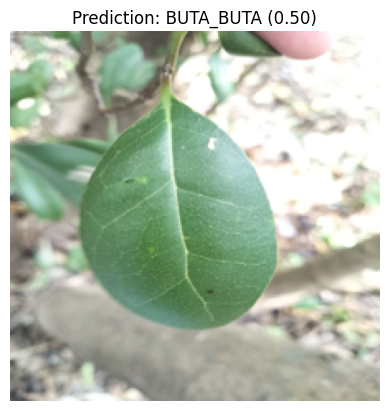

✅ Predicted: BUTA_BUTA (Confidence: 0.50)


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# ================================
# Upload local image
# ================================
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # get uploaded filename

# ================================
# Prediction function with display
# ================================
def predict_tflite(image_path):
    # Load and preprocess image
    img = Image.open(image_path).convert("RGB").resize((224, 224))
    input_data = np.expand_dims(np.array(img, dtype=np.float32), axis=0)
    input_data = (input_data / 127.5) - 1.0  # ✅ same preprocess as training

    # Run TFLite inference
    interpreter = tf.lite.Interpreter(model_path="/content/drive/MyDrive/MLMODEL/mangrove_model.tflite")
    interpreter.allocate_tensors()

    input_index = interpreter.get_input_details()[0]['index']
    output_index = interpreter.get_output_details()[0]['index']

    interpreter.set_tensor(input_index, input_data)
    interpreter.invoke()
    preds = interpreter.get_tensor(output_index)[0]

    # Get best class
    class_id = np.argmax(preds)
    confidence = preds[class_id]

    # ================================
    # Display image with prediction
    # ================================
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {class_names[class_id]} ({confidence:.2f})")
    plt.show()

    return class_id, confidence

# ================================
# Run prediction
# ================================
class_id, conf = predict_tflite(image_path)
print(f"✅ Predicted: {class_names[class_id]} (Confidence: {conf:.2f})")
